# Feature Retrain Notebook
Retrain XGBoost on the **top features identified by SHAP + LIME** in `lime_shap_analysis.ipynb`,
then benchmark the retrained model against the baseline.

**Inputs:**
- `results/lime_shap/feature_comparison_table.csv` — composite feature ranking from lime_shap
- `data/dataset/*.csv` — original CIC-IDS2017 training data
- `data/flows.csv` *(optional)* — VM-generated flows for out-of-distribution evaluation
- `models/baseline_xgboost.json` + `models/preprocessing_info.pkl` — baseline to compare against

**Outputs:**
- `models/retrained_model.json`
- `models/retrained_preprocessing_info.pkl`
- `output/retrain/` — comparison plots, per-class table, summary report

In [3]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') # Move up one level to the project root

print("Corrected Working Directory:", os.getcwd())

Corrected Working Directory: /home/masko/Spring 2026/cpre560/IDS-ML


In [4]:
# === CELL 1: Imports ===
import gc, pickle, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'font.size': 11,
})
print('Imports OK')

Imports OK


In [6]:
# === CELL 2: Configuration ===

# ── Feature selection ────────────────────────────────────────────────────
# How many top features from the SHAP/LIME composite ranking to keep.
# Try 20, 30, or 40 — lower = faster training, may lose some accuracy.
TOP_N_FEATURES   = 20

# Which column in feature_comparison_table.csv to rank by.
# Options: 'Composite' | 'CIC_SHAP' | 'VM_SHAP' | 'CIC_LIME' | 'VM_LIME'
RANK_BY          = 'Composite'

# ── Training ─────────────────────────────────────────────────────────────
SAMPLE_FRACTION  = 0.10   # fraction of CIC data to train on (same as baseline)
TEST_SIZE        = 0.20
RANDOM_STATE     = 42
MIN_SMOTE        = 50     # classes below this skip SMOTE, use class weighting

# ── Paths ────────────────────────────────────────────────────────────────
FEATURE_TABLE    = 'output/lime_shap/feature_comparison_table.csv'
DATA_PATH        = Path('data/dataset')
VM_CSV           = 'data/flows.csv'    # set to None to skip VM evaluation
BASELINE_MODEL   = 'models/baseline_xgboost.json'
ARTIFACTS_PATH   = 'models/preprocessing_info.pkl'
RENAME_MAP_PATH  = 'src/preprocessing/rename_map.pkl'
OUT_MODELS       = Path('models')
OUT_DIR          = Path('output/retrain')
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [FEATURE_TABLE, BASELINE_MODEL, ARTIFACTS_PATH, RENAME_MAP_PATH]:
    if not Path(p).exists():
        raise FileNotFoundError(f'Required file not found: {p}')

print('Config OK')
print(f'  TOP_N_FEATURES  : {TOP_N_FEATURES}')
print(f'  RANK_BY         : {RANK_BY}')
print(f'  SAMPLE_FRACTION : {SAMPLE_FRACTION}')
print(f'  Output dir      : {OUT_DIR.absolute()}')

Config OK
  TOP_N_FEATURES  : 20
  RANK_BY         : Composite
  SAMPLE_FRACTION : 0.1
  Output dir      : /home/masko/Spring 2026/cpre560/IDS-ML/output/retrain


In [7]:
# === CELL 3: Load Baseline Artifacts ===
baseline_model = xgb.XGBClassifier()
baseline_model.load_model(BASELINE_MODEL)

with open(ARTIFACTS_PATH, 'rb') as f:
    artifacts = pickle.load(f)

le_target        = artifacts['target_encoder']
all_feature_cols = artifacts['feature_columns']   # full 80-feature set
cat_encoders     = artifacts.get('categorical_encoders', {})
cat_cols         = artifacts.get('categorical_columns', [])

with open(RENAME_MAP_PATH, 'rb') as f:
    rename_map = pickle.load(f)

class_names = list(le_target.classes_)
n_classes   = len(class_names)

print(f'Baseline loaded')
print(f'  Classes ({n_classes}) : {class_names}')
print(f'  Full feature set : {len(all_feature_cols)} columns')

Baseline loaded
  Classes (12) : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack Brute Force', 'Web Attack XSS']
  Full feature set : 78 columns


Feature table shape : (78, 14)
Valid features found : 78 / 78

Top 20 features (ranked by Composite):
-------------------------------------------------------
   1. Destination Port                         0.6110  [BOTH]
   2. Total Length of Fwd Packets              0.4577  [VM-ONLY]
   3. Fwd Packet Length Max                    0.4001  [BOTH]
   4. Bwd Packet Length Std                    0.3271  [BOTH]
   5. FIN Flag Count                           0.3127  [BOTH]
   6. Flow Bytes/s                             0.3094  [BOTH]
   7. Flow Duration                            0.2837  [VM-ONLY]
   8. Bwd Packets/s                            0.2771  [BOTH]
   9. min_seg_size_forward                     0.2602  [CIC-ONLY]
  10. Init_Win_bytes_backward                  0.2481  [BOTH]
  11. Init_Win_bytes_forward                   0.1954  [CIC-ONLY]
  12. Flow IAT Std                             0.1914  [VM-ONLY]
  13. Flow IAT Mean                            0.1760  [BOTH]
  14. Total Length 

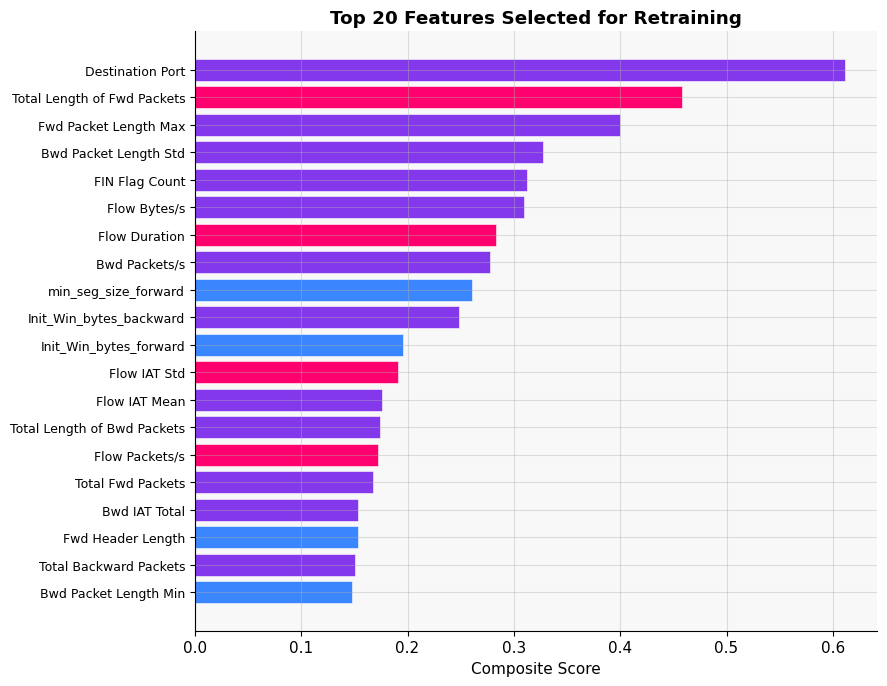

In [8]:
# === CELL 4: Select Top Features from SHAP/LIME Table ===
feat_tbl = pd.read_csv(FEATURE_TABLE, index_col=0)

if RANK_BY not in feat_tbl.columns:
    raise ValueError(f"'{RANK_BY}' not in feature table. Available: {list(feat_tbl.columns)}")

feat_tbl_sorted = feat_tbl.sort_values(RANK_BY, ascending=False)

# Only keep features that exist in the model's feature set
valid_features  = [f for f in feat_tbl_sorted.index if f in all_feature_cols]
top_features    = valid_features[:TOP_N_FEATURES]

dropped_features = [f for f in all_feature_cols if f not in top_features]

print(f'Feature table shape : {feat_tbl.shape}')
print(f'Valid features found : {len(valid_features)} / {len(all_feature_cols)}')
print(f'\nTop {TOP_N_FEATURES} features (ranked by {RANK_BY}):')
print('-' * 55)
for i, feat in enumerate(top_features, 1):
    score    = feat_tbl_sorted.loc[feat, RANK_BY]
    presence = feat_tbl_sorted.loc[feat, 'Presence'] if 'Presence' in feat_tbl_sorted.columns else '—'
    print(f'  {i:>2}. {feat:<40} {score:.4f}  [{presence}]')

print(f'\nDropped {len(dropped_features)} features')

# Bar chart of selected features
fig, ax = plt.subplots(figsize=(9, max(4, TOP_N_FEATURES * 0.35)))
scores  = feat_tbl_sorted.loc[top_features, RANK_BY]
colors  = ['#8338EC' if feat_tbl_sorted.loc[f, 'Presence'] == 'BOTH'
           else '#3A86FF' if feat_tbl_sorted.loc[f, 'Presence'] == 'CIC-ONLY'
           else '#FF006E' if feat_tbl_sorted.loc[f, 'Presence'] == 'VM-ONLY'
           else '#aaaaaa'
           for f in top_features] if 'Presence' in feat_tbl_sorted.columns \
           else ['#3A86FF'] * len(top_features)
ax.barh(range(len(top_features)), scores.values[::-1][::-1],
        color=colors, edgecolor='white', linewidth=0.4)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(f'{RANK_BY} Score')
ax.set_title(f'Top {TOP_N_FEATURES} Features Selected for Retraining', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'selected_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# === CELL 5: Load & Preprocess CIC Data ===
print('Loading CIC-IDS2017 data...')
csv_files = sorted(DATA_PATH.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError(f'No CSVs found in {DATA_PATH.absolute()}')

dfs = []
for filepath in csv_files:
    print(f'  {filepath.name[:60]:60s}...', end=' ', flush=True)
    try:
        df = pd.read_csv(filepath, low_memory=False, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, low_memory=False, encoding='latin-1')
    df.columns = df.columns.str.strip()
    dfs.append(df)
    print(f'{len(df):,} rows')
    gc.collect()

df_all = pd.concat(dfs, ignore_index=True)
del dfs; gc.collect()

# Normalise label column
raw_label = df_all.columns[-1]
df_all.rename(columns={raw_label: 'Label'}, inplace=True)
label_map = {
    'Web Attack \x96 Brute Force':   'Web Attack Brute Force',
    'Web Attack \x96 Sql Injection': 'Web Attack Sql Injection',
    'Web Attack \x96 XSS':          'Web Attack XSS',
}
df_all['Label'] = df_all['Label'].str.strip().replace(label_map)
df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
df_all.dropna(inplace=True)

# Per-class sample (same fraction as baseline)
df_all = pd.concat([
    grp.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE)
    for _, grp in df_all.groupby('Label', group_keys=False)
]).reset_index(drop=True)
gc.collect()

print(f'\nCombined shape after sampling : {df_all.shape}')
print(f'Label distribution:')
display(df_all['Label'].value_counts().rename_axis('Class').reset_index(name='Count'))

Loading CIC-IDS2017 data...
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv            ... 225,745 rows
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv        ... 286,467 rows
  Friday-WorkingHours-Morning.pcap_ISCX.csv                   ... 191,033 rows
  Monday-WorkingHours.pcap_ISCX.csv                           ... 529,918 rows
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ... 288,602 rows
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv      ... 170,366 rows
  Tuesday-WorkingHours.pcap_ISCX.csv                          ... 445,909 rows
  Wednesday-workingHours.pcap_ISCX.csv                        ... 692,703 rows

Combined shape after sampling : (282788, 79)
Label distribution:


,Class,Count
0,BENIGN,227132
1,DoS Hulk,23012
2,PortScan,15880
3,DDoS,12802
4,DoS GoldenEye,1029
5,FTP-Patator,794
6,SSH-Patator,590
7,DoS slowloris,580
8,DoS Slowhttptest,550
9,Bot,196


In [12]:
# === CELL 6: Build Feature Matrices (full vs top-N) ===
y_raw     = df_all['Label']
y_encoded = le_target.transform(
    y_raw.apply(lambda x: x if x in set(le_target.classes_) else le_target.classes_[0])
)

# Encode categoricals
for col in cat_cols:
    if col in df_all.columns and col in cat_encoders:
        enc    = cat_encoders[col]
        known  = set(enc.classes_)
        df_all[col] = df_all[col].astype(str).apply(
            lambda x: x if x in known else enc.classes_[0])
        df_all[col] = enc.transform(df_all[col])

# Full feature matrix (for baseline re-evaluation on same test set)
missing_full = [c for c in all_feature_cols if c not in df_all.columns]
if missing_full:
    print(f'[!] Adding {len(missing_full)} missing columns as 0: {missing_full[:3]}')
    for c in missing_full: df_all[c] = 0

X_full = df_all[all_feature_cols].fillna(df_all[all_feature_cols].median(numeric_only=True))

# Reduced feature matrix
X_top  = df_all[top_features].fillna(df_all[top_features].median(numeric_only=True))

print(f'Full feature matrix : {X_full.shape}')
print(f'Reduced feature matrix : {X_top.shape}')

# Shared train/test split — same indices for fair comparison
idx = np.arange(len(X_full))
idx_train, idx_test = train_test_split(
    idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded)

X_full_train, X_full_test = X_full.iloc[idx_train], X_full.iloc[idx_test]
X_top_train,  X_top_test  = X_top.iloc[idx_train],  X_top.iloc[idx_test]
y_train,       y_test      = y_encoded[idx_train],    y_encoded[idx_test]

print(f'Train : {len(idx_train):,}  |  Test : {len(idx_test):,}')
gc.collect()

Full feature matrix : (282788, 78)
Reduced feature matrix : (282788, 20)
Train : 226,230  |  Test : 56,558


0

In [13]:
# === CELL 7: SMOTE Balancing (reduced feature set) ===
train_counts   = np.bincount(y_train)
majority_count = train_counts.max()
target_count   = max(int(majority_count * 0.05), 500)

sampling_strategy = {}
for i, name in enumerate(le_target.classes_):
    if i >= len(train_counts): continue
    count = train_counts[i]
    if MIN_SMOTE <= count < target_count:
        sampling_strategy[i] = target_count
    elif count < MIN_SMOTE:
        print(f'  {name}: {count} (too few for SMOTE — class weighting only)')

if sampling_strategy:
    k = min(5, min(train_counts[i] for i in sampling_strategy) - 1)
    smote = SMOTE(sampling_strategy=sampling_strategy,
                  random_state=RANDOM_STATE, k_neighbors=k)
    X_top_bal, y_bal = smote.fit_resample(X_top_train, y_train)
    print(f'SMOTE: {len(X_top_train):,} → {len(X_top_bal):,} samples')
else:
    X_top_bal, y_bal = X_top_train.values, y_train
    print('No SMOTE needed')

# Sample weights
bal_counts     = np.bincount(y_bal)
total_bal      = bal_counts.sum()
n_cls          = len(bal_counts)
sample_weights = np.array([total_bal / (n_cls * bal_counts[y]) for y in y_bal])
gc.collect()

SMOTE: 226,230 → 277,803 samples


0

In [14]:
# === CELL 8: Train Retrained Model ===
print('Training retrained model on top features...')
retrained_model = xgb.XGBClassifier(
    n_estimators  = 100,
    max_depth     = 6,
    learning_rate = 0.1,
    tree_method   = 'hist',
    objective     = 'multi:softmax',
    num_class     = n_classes,
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
    eval_metric   = 'mlogloss',
    verbosity     = 0,
)
t0 = time.time()
retrained_model.fit(X_top_bal, y_bal,
                    sample_weight=sample_weights, verbose=False)
train_time = time.time() - t0
print(f'Done in {train_time:.1f}s')
gc.collect()

Training retrained model on top features...
Done in 28.9s


28

In [17]:
# === CELL 9: Evaluate Both Models on Same Test Set ===
import pandas as pd
if not hasattr(pd.io.formats.style.Styler, 'map'):
    pd.io.formats.style.Styler.map = pd.io.formats.style.Styler.applymap

# Baseline predictions on full features
t0 = time.time()
y_pred_base = baseline_model.predict(X_full_test)
base_time   = time.time() - t0

# Retrained predictions on top features
t0 = time.time()
y_pred_ret  = retrained_model.predict(X_top_test)
ret_time    = time.time() - t0

def metrics(y_true, y_pred, speed_s, n_samples):
    return {
        'Accuracy'         : accuracy_score(y_true, y_pred),
        'Macro F1'         : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'Weighted F1'      : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Macro Precision'  : precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall'     : recall_score(y_true, y_pred,    average='macro', zero_division=0),
        'Samples/sec'      : round(n_samples / speed_s),
    }

n     = len(y_test)
m_b   = metrics(y_test, y_pred_base, base_time, n)
m_r   = metrics(y_test, y_pred_ret,  ret_time,  n)

cmp = pd.DataFrame({'Baseline': m_b, 'Retrained': m_r})
cmp['Delta'] = cmp['Retrained'] - cmp['Baseline']

print('=' * 55)
print(f'  Baseline features  : {len(all_feature_cols)}')
print(f'  Retrained features : {len(top_features)}')
print('=' * 55)
display(cmp.style
        .format(lambda v: f'{v*100:.2f}%' if abs(v) < 100 else f'{v:,.0f}',
                subset=['Baseline','Retrained'])
        .format(lambda v: f'{v*100:+.2f}%' if abs(v) < 100 else f'{v:+,.0f}',
                subset=['Delta'])
        .map(lambda v: 'color:green' if isinstance(v, float) and v > 0
             else ('color:red' if isinstance(v, float) and v < 0 else ''),
             subset=['Delta']))

cmp.to_csv(OUT_DIR / 'model_comparison.csv')
print('Saved → output/retrain/model_comparison.csv')

  Baseline features  : 78
  Retrained features : 20


,Baseline,Retrained,Delta
Accuracy,99.72%,99.78%,+0.06%
Macro F1,79.19%,94.68%,+15.49%
Weighted F1,99.79%,99.81%,+0.02%
Macro Precision,77.46%,92.66%,+15.20%
Macro Recall,83.29%,99.86%,+16.57%
Samples/sec,"300,347","523,452","+223,105"


Saved → output/retrain/model_comparison.csv


In [19]:
# === CELL 10: Per-Class Performance Comparison ===
def per_class_df(y_true, y_pred):
    present_labels = sorted(set(y_true) | set(y_pred))   # classes that actually appear
    present_names  = [class_names[i] for i in present_labels]

    report = classification_report(y_true, y_pred,
                                   labels=present_labels,     # add this
                                   target_names=present_names, # scoped to match
                                   output_dict=True, zero_division=0)
    rows = []
    for cls in class_names:          # still iterates all 12 — missing ones → zeros
        r = report.get(cls, {})
        rows.append({
            'Class':     cls,
            'Precision': round(r.get('precision', 0) * 100, 2),
            'Recall':    round(r.get('recall',    0) * 100, 2),
            'F1':        round(r.get('f1-score',  0) * 100, 2),
            'Support':   int(r.get('support',     0)),
        })
    return pd.DataFrame(rows).set_index('Class')

pc_base = per_class_df(y_test, y_pred_base).add_suffix('_Base')
pc_ret  = per_class_df(y_test, y_pred_ret ).add_suffix('_Ret')
pc_cmp  = pc_base.join(pc_ret)
pc_cmp['F1_Delta'] = (pc_cmp['F1_Ret'] - pc_cmp['F1_Base']).round(2)
pc_cmp.drop(columns=['Support_Ret'], inplace=True, errors='ignore')
pc_cmp.rename(columns={'Support_Base': 'Support'}, inplace=True)

print('Per-class comparison (Baseline vs Retrained):')
display(pc_cmp.style
        .background_gradient(subset=['F1_Base','F1_Ret'], cmap='RdYlGn', vmin=0, vmax=100)
        .map(lambda v: 'color:green;font-weight:bold' if isinstance(v,(int,float)) and v > 0   # ← map
             else ('color:red;font-weight:bold' if isinstance(v,(int,float)) and v < 0 else ''),
             subset=['F1_Delta'])
        .format('{:.2f}', subset=[c for c in pc_cmp.columns if c != 'Support']))

pc_cmp.to_csv(OUT_DIR / 'per_class_comparison.csv')
print('Saved → output/retrain/per_class_comparison.csv')

Per-class comparison (Baseline vs Retrained):


,Precision_Base,Recall_Base,F1_Base,Support,Precision_Ret,Recall_Ret,F1_Ret,F1_Delta
Class,,,,,,,,
BENIGN,100.00,99.67,99.83,45471,99.99,99.74,99.87,0.04
Bot,37.50,100.00,54.55,39,34.82,100.00,51.66,-2.89
DDoS,99.81,100.00,99.90,2560,99.77,100.00,99.88,-0.02
DoS GoldenEye,98.10,100.00,99.04,206,98.56,100.00,99.28,0.24
DoS Hulk,99.50,99.93,99.72,4603,99.52,100.00,99.76,0.04
DoS Slowhttptest,98.21,100.00,99.10,110,100.00,99.09,99.54,0.44
DoS slowloris,96.67,100.00,98.31,116,95.08,100.00,97.48,-0.83
FTP-Patator,100.00,100.00,100.00,159,100.00,100.00,100.00,0.00
PortScan,99.69,99.91,99.80,3176,99.69,99.81,99.75,-0.05


Saved → output/retrain/per_class_comparison.csv


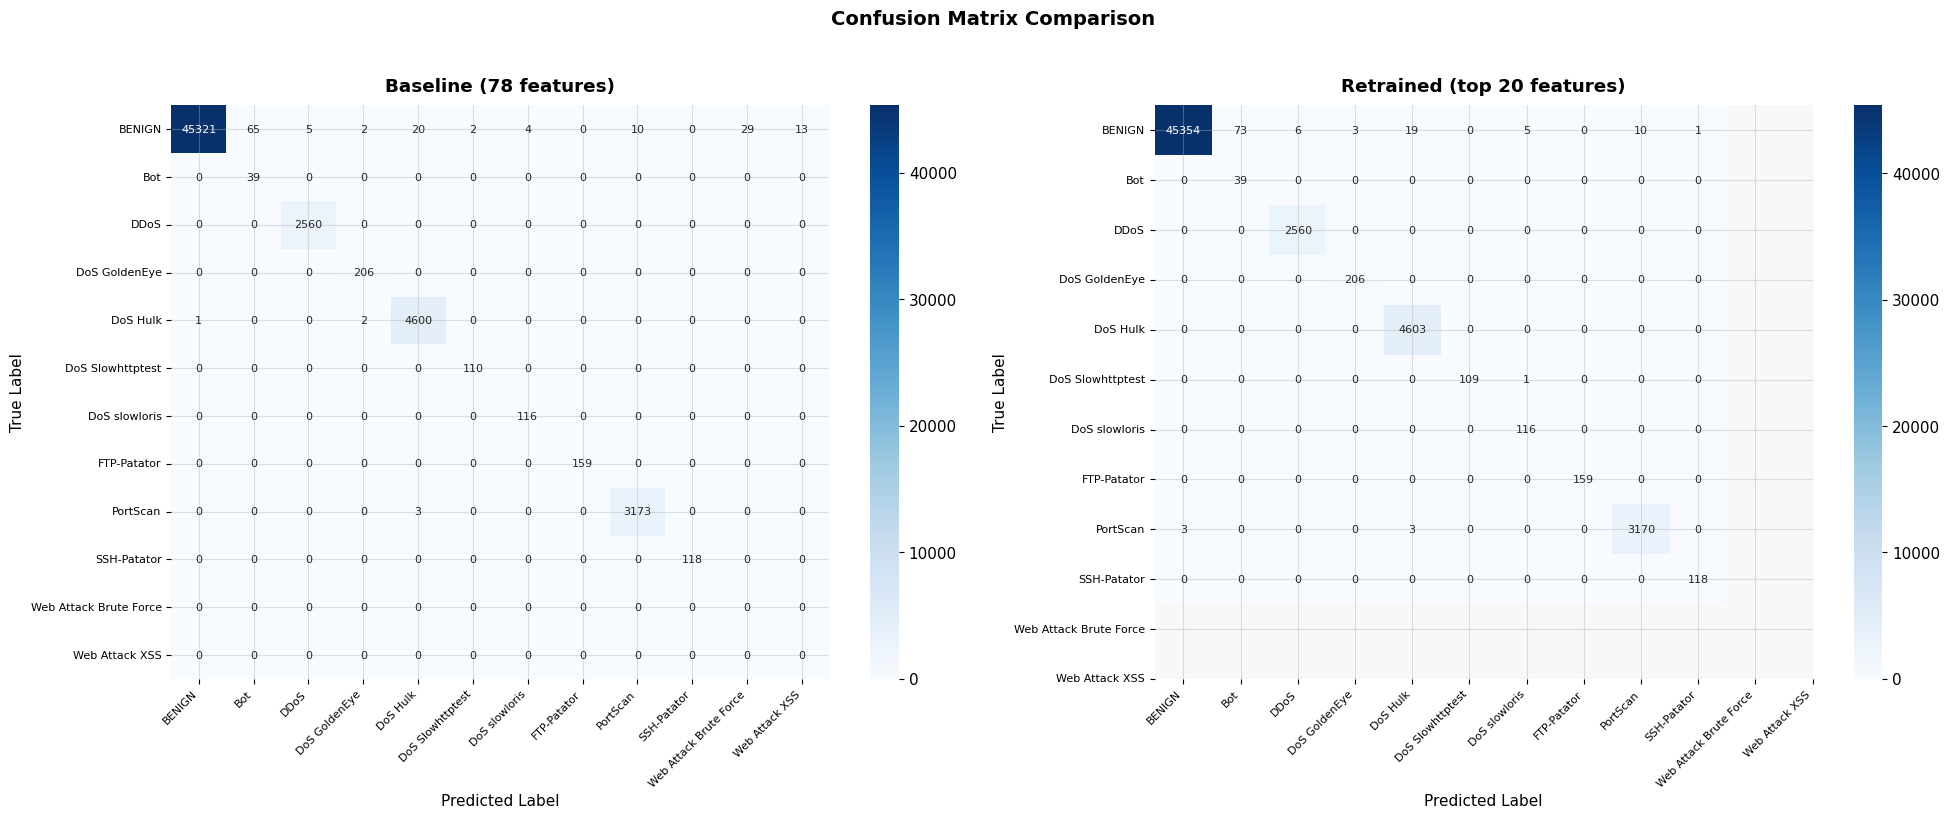

In [20]:
# === CELL 11: Side-by-Side Confusion Matrices ===
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, y_pred, title in [
    (axes[0], y_pred_base, f'Baseline ({len(all_feature_cols)} features)'),
    (axes[1], y_pred_ret,  f'Retrained (top {len(top_features)} features)'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                annot_kws={'size': 8})
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

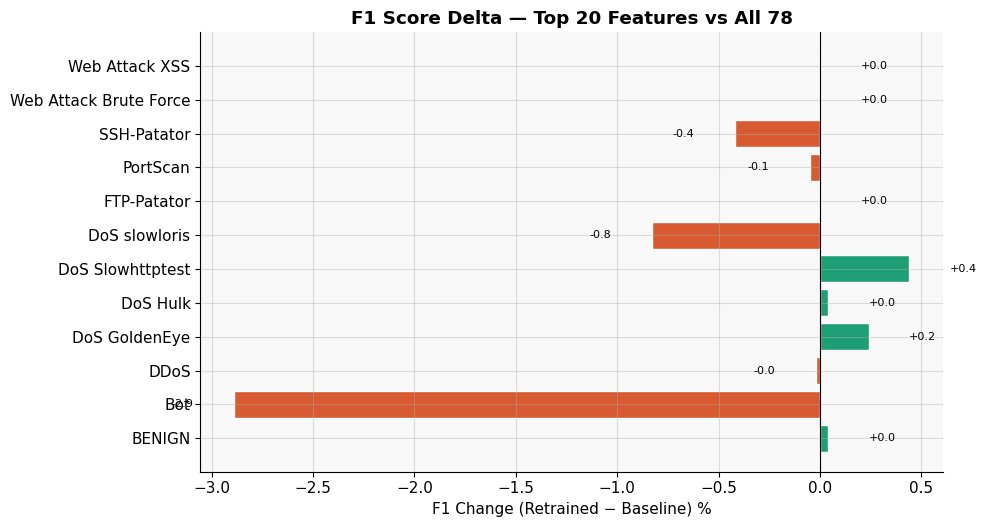

In [21]:
# === CELL 12: F1 Delta Bar Chart ===
fig, ax = plt.subplots(figsize=(10, max(4, len(class_names) * 0.45)))
colors  = ['#1D9E75' if v >= 0 else '#D85A30' for v in pc_cmp['F1_Delta']]
ax.barh(pc_cmp.index, pc_cmp['F1_Delta'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('F1 Change (Retrained − Baseline) %')
ax.set_title(f'F1 Score Delta — Top {len(top_features)} Features vs All {len(all_feature_cols)}',
             fontweight='bold')
for i, (cls, row) in enumerate(pc_cmp.iterrows()):
    v = row['F1_Delta']
    ax.text(v + (0.2 if v >= 0 else -0.2), i, f'{v:+.1f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'f1_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# === CELL 13: VM Out-of-Distribution Evaluation (optional) ===
has_vm = VM_CSV is not None and Path(VM_CSV).exists()

if not has_vm:
    print(f'VM CSV not found at {VM_CSV} — skipping VM evaluation.')
else:
    df_vm = pd.read_csv(VM_CSV, low_memory=False)
    df_vm.columns = df_vm.columns.str.strip()
    df_vm.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_vm.rename(columns=rename_map, inplace=True)
    if 'Fwd Header Length' in df_vm.columns:
        df_vm['Fwd Header Length.1'] = df_vm['Fwd Header Length']

    has_gt_vm = 'Label' in df_vm.columns

    # Full features for baseline
    for c in [f for f in all_feature_cols if f not in df_vm.columns]:
        df_vm[c] = 0
    X_vm_full = df_vm[all_feature_cols].fillna(0)

    # Top features for retrained
    for c in [f for f in top_features if f not in df_vm.columns]:
        df_vm[c] = 0
    X_vm_top  = df_vm[top_features].fillna(0)

    pred_vm_base = le_target.inverse_transform(baseline_model.predict(X_vm_full))
    pred_vm_ret  = le_target.inverse_transform(retrained_model.predict(X_vm_top))

    print(f'VM flows: {len(df_vm):,}')
    print('\nBaseline predictions on VM data:')
    display(pd.Series(pred_vm_base).value_counts().rename_axis('Predicted').reset_index(name='Count'))
    print('\nRetrained predictions on VM data:')
    display(pd.Series(pred_vm_ret).value_counts().rename_axis('Predicted').reset_index(name='Count'))

    if has_gt_vm:
        y_vm_true = df_vm['Label'].astype(str).str.strip()
        known     = set(le_target.classes_)
        y_vm_enc  = le_target.transform(
            y_vm_true.apply(lambda x: x if x in known else le_target.classes_[0]))
        y_vm_pred_base_enc = baseline_model.predict(X_vm_full)
        y_vm_pred_ret_enc  = retrained_model.predict(X_vm_top)

        m_vm_b = metrics(y_vm_enc, y_vm_pred_base_enc, 1, len(y_vm_enc))
        m_vm_r = metrics(y_vm_enc, y_vm_pred_ret_enc,  1, len(y_vm_enc))
        cmp_vm = pd.DataFrame({'Baseline_VM': m_vm_b, 'Retrained_VM': m_vm_r})
        cmp_vm['Delta'] = cmp_vm['Retrained_VM'] - cmp_vm['Baseline_VM']
        print('\nVM evaluation metrics:')
        display(cmp_vm.style.format('{:.4f}'))
        cmp_vm.to_csv(OUT_DIR / 'vm_comparison.csv')
        print('Saved → output/retrain/vm_comparison.csv')

VM flows: 117,274

Baseline predictions on VM data:


,Predicted,Count
0,BENIGN,117217
1,FTP-Patator,29
2,DoS Hulk,28



Retrained predictions on VM data:


,Predicted,Count
0,BENIGN,117245
1,FTP-Patator,29



VM evaluation metrics:


,Baseline_VM,Retrained_VM,Delta
Accuracy,0.0140,0.0142,0.0002
Macro F1,0.0511,0.0511,0.0000
Weighted F1,0.0004,0.0004,0.0000
Macro Precision,0.0322,0.0322,0.0000
Macro Recall,0.2206,0.2222,0.0016
Samples/sec,117274.0000,117274.0000,0.0000


Saved → output/retrain/vm_comparison.csv


In [23]:
# === CELL 14: Save Retrained Model & Artifacts ===
retrained_model.save_model(str(OUT_MODELS / 'retrained_model.json'))
print('Saved → models/retrained_model.json')

retrained_artifacts = {
    'categorical_encoders': cat_encoders,
    'target_encoder':       le_target,
    'feature_columns':      top_features,   # reduced feature set
    'categorical_columns':  cat_cols,
    'retrain_config': {
        'top_n_features':  TOP_N_FEATURES,
        'rank_by':         RANK_BY,
        'sample_fraction': SAMPLE_FRACTION,
    }
}
with open(OUT_MODELS / 'retrained_preprocessing_info.pkl', 'wb') as f:
    pickle.dump(retrained_artifacts, f)
print('Saved → models/retrained_preprocessing_info.pkl')
print(f'\nTo run inference with the retrained model, point inference.ipynb at:')
print(f'  MODEL_PATH     = "models/retrained_model.json"')
print(f'  ARTIFACTS_PATH = "models/retrained_preprocessing_info.pkl"')

Saved → models/retrained_model.json
Saved → models/retrained_preprocessing_info.pkl

To run inference with the retrained model, point inference.ipynb at:
  MODEL_PATH     = "models/retrained_model.json"
  ARTIFACTS_PATH = "models/retrained_preprocessing_info.pkl"


In [24]:
# === CELL 15: Summary Report ===
acc_delta = (m_r['Accuracy']  - m_b['Accuracy'])  * 100
f1_delta  = (m_r['Macro F1'] - m_b['Macro F1']) * 100
improved  = pc_cmp[pc_cmp['F1_Delta'] > 0].index.tolist()
degraded  = pc_cmp[pc_cmp['F1_Delta'] < 0].index.tolist()

report = f"""
{'='*60}
  RETRAIN SUMMARY
{'='*60}
  Feature reduction   : {len(all_feature_cols)} → {len(top_features)}
  Rank strategy       : {RANK_BY}
  Train time          : {train_time:.1f}s

  Metric             Baseline   Retrained   Delta
  {'─'*45}
  Accuracy         {m_b['Accuracy']*100:>8.2f}%  {m_r['Accuracy']*100:>9.2f}%  {acc_delta:>+6.2f}%
  Macro F1         {m_b['Macro F1']*100:>8.2f}%  {m_r['Macro F1']*100:>9.2f}%  {f1_delta:>+6.2f}%
  Macro Precision  {m_b['Macro Precision']*100:>8.2f}%  {m_r['Macro Precision']*100:>9.2f}%  {(m_r['Macro Precision']-m_b['Macro Precision'])*100:>+6.2f}%
  Macro Recall     {m_b['Macro Recall']*100:>8.2f}%  {m_r['Macro Recall']*100:>9.2f}%  {(m_r['Macro Recall']-m_b['Macro Recall'])*100:>+6.2f}%
  Speed (samp/s)   {m_b['Samples/sec']:>8,.0f}   {m_r['Samples/sec']:>9,.0f}

  Classes improved  : {improved if improved else 'none'}
  Classes degraded  : {degraded if degraded else 'none'}

  Output files → output/retrain/
    confusion_matrix_comparison.png
    f1_delta.png
    model_comparison.csv
    per_class_comparison.csv
    selected_features.png
{'='*60}
"""
print(report)
with open(OUT_DIR / 'retrain_summary.txt', 'w') as f:
    f.write(report)
print('Saved → output/retrain/retrain_summary.txt')


  RETRAIN SUMMARY
  Feature reduction   : 78 → 20
  Rank strategy       : Composite
  Train time          : 28.9s

  Metric             Baseline   Retrained   Delta
  ─────────────────────────────────────────────
  Accuracy            99.72%      99.78%   +0.06%
  Macro F1            79.19%      94.68%  +15.49%
  Macro Precision     77.46%      92.66%  +15.20%
  Macro Recall        83.29%      99.86%  +16.57%
  Speed (samp/s)    300,347     523,452

  Classes improved  : ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest']
  Classes degraded  : ['Bot', 'DDoS', 'DoS slowloris', 'PortScan', 'SSH-Patator']

  Output files → output/retrain/
    confusion_matrix_comparison.png
    f1_delta.png
    model_comparison.csv
    per_class_comparison.csv
    selected_features.png

Saved → output/retrain/retrain_summary.txt
